In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import subprocess
from scipy.stats import chisquare
import os
import glob

# import scipy.stats as stats

In [3]:
%load_ext autoreload

%autoreload 2
import pandas as pd
import numpy as np
%aimport Variant_analysis_helper_functions


#import protfasta
import os

# Running enrichment analysis scripts

In [3]:
! python3 ../scripts/get_full_mutations.py --variants_filename expanded_iWES_v3_variants.bed  --variants_folder /Users/sanjanakotha/Desktop/Staller_Lab/SFARI/soto_analysis/raw_files/ --sort_TFs true --sort_variants true

Sorting TF bed files.
1 ENST00000326775
2 ENST00000243056
3 ENST00000311331
4 ENST00000302342
5 ENST00000012134
6 ENST00000310826
7 ENST00000335953
8 ENST00000610704
9 ENST00000328086
10 ENST00000281523
11 ENST00000344930
12 ENST00000588221
13 ENST00000239882
14 ENST00000260643
15 ENST00000329198
16 ENST00000237316
17 ENST00000302177
18 ENST00000265755
19 ENST00000262570
20 ENST00000406360
21 ENST00000332372
22 ENST00000392842
23 ENST00000270617
24 ENST00000372469
25 ENST00000359486
26 ENST00000415922
27 ENST00000040584
28 ENST00000293471
29 ENST00000329705
30 ENST00000357727
31 ENST00000311764
32 ENST00000342665
33 ENST00000266744
34 ENST00000434436
35 ENST00000314686
36 ENST00000415914
37 ENST00000242728
38 ENST00000524983
39 ENST00000372699
40 ENST00000427442
41 ENST00000297689
42 ENST00000330070
43 ENST00000373125
44 ENST00000226067
45 ENST00000448943
46 ENST00000377115
47 ENST00000451604
48 ENST00000367387
49 ENST00000338010
50 ENST00000250448
51 ENST00000368136
52 ENST00000367942

In [4]:
! python3 ../scripts/classify_mutations.py --variants_filename expanded_iWES_v3_variants.bed

1 ENST00000296096.bed
2 ENST00000419098.bed
3 ENST00000259803.bed
4 ENST00000698516.bed
5 ENST00000506184.bed
6 ENST00000443427.bed
7 ENST00000234392.bed
8 ENST00000675105.bed
9 ENST00000295206.bed
10 ENST00000361387.bed
11 ENST00000530393.bed
12 ENST00000434687.bed
13 ENST00000268638.bed
14 ENST00000474710.bed
15 ENST00000162391.bed
16 ENST00000448943.bed
17 ENST00000543802.bed
18 ENST00000400085.bed
19 ENST00000356073.bed
20 ENST00000418153.bed
21 ENST00000698099.bed
22 ENST00000399602.bed
23 ENST00000503201.bed
24 ENST00000436292.bed
25 ENST00000241527.bed
26 ENST00000321358.bed
27 ENST00000283921.bed
28 ENST00000538320.bed
29 ENST00000444957.bed
30 ENST00000360338.bed
31 ENST00000342833.bed
32 ENST00000398468.bed
33 ENST00000377687.bed
34 ENST00000358664.bed
35 ENST00000411995.bed
36 ENST00000492450.bed
37 ENST00000508793.bed
38 .bed
39 ENST00000369888.bed
40 ENST00000362063.bed
41 ENST00000602212.bed
42 ENST00000672722.bed
43 ENST00000302754.bed
44 ENST00000587539.bed
45 ENST00000

In [6]:
! mkdir ../outputs/mutations/domains_expanded_iWES_v3_variants_snv_classified/

In [7]:
! python3 ../scripts/get_mutations_domains_snv_classified.py --domain none --variants_filename expanded_iWES_v3_variants.bed

1 O15062
2 Q86XF7
3 Q5XKR4
4 Q5TA89
5 O43623
6 O14978
7 Q8N587
8 P37231
9 Q86YP4
10 Q8IWY8
11 Q9UEG4
12 P19793
13 C9JLR9
14 Q16665
15 O75346
16 P10242
17 P16989
18 P10070
19 Q96MA1
20 Q96CK0
21 Q12800
22 Q96MM3
23 Q14938
24 Q6NSZ9
25 Q9NRM2
26 P0CI00
27 Q96DT7
28 Q96SZ4
29 P51449
30 Q499Z4
31 Q9BXG8
32 Q86UZ6
33 Q9BWX5
34 Q49AG3
35 Q14593
36 Q5TC79
37 O95935
38 O15266
39 Q9HBE1
40 P12524
41 Q96BR9
42 Q96LX8
43 Q6VB84
44 O14529
45 Q8NB50
46 Q86VE0
47 Q5SVQ8
48 Q8IW36
49 Q96N22
50 Q8WTV1
51 Q8N1W2
52 Q9P0T4
53 P61244
54 P52630
55 Q16600
56 Q96KM6
57 O14770
58 Q9UFW8
59 Q9UBR4
60 Q9BQW3
61 Q8TBC5
62 O14545
63 P15336
64 Q9UMN6
65 A8MTQ0
66 Q9UL49
67 Q2KHR2
68 Q9GZZ0
69 Q86WP2
70 Q9H4T2
71 P10827
72 Q9BU19
73 P58304
74 Q9UL40
75 P78367
76 O43670
77 A6NP11
78 Q6BEB4
79 P18847
80 Q15424
81 Q32MQ0
82 P11308
83 O15499
84 Q15047
85 P20226
86 Q3SY52
87 Q9P0W2
88 Q8N143
89 A0AVK6
90 Q86UP8
91 Q03989
92 Q8N782
93 Q6ZN79
94 Q15672
95 Q14592
96 P13631
97 P02788
98 Q9BWW7
99 Q9P016
100 Q12830
101 Q96N

---
# Building table

In [4]:
# Only keep TFs with ADs
all_TFs = pd.read_csv("../outputs/all_TFs_table_proteins_activators.txt", sep = "\t")
activator_TF_ENSTs = set(all_TFs["ENST"])
activator_TF_ENSTs

{'ENST00000008391',
 'ENST00000056233',
 'ENST00000078445',
 'ENST00000162391',
 'ENST00000177694',
 'ENST00000201031',
 'ENST00000206513',
 'ENST00000216037',
 'ENST00000216513',
 'ENST00000217026',
 'ENST00000219905',
 'ENST00000221452',
 'ENST00000221996',
 'ENST00000222122',
 'ENST00000222305',
 'ENST00000222718',
 'ENST00000222728',
 'ENST00000223357',
 'ENST00000226067',
 'ENST00000226247',
 'ENST00000228641',
 'ENST00000228644',
 'ENST00000228682',
 'ENST00000228741',
 'ENST00000229307',
 'ENST00000231656',
 'ENST00000234392',
 'ENST00000239165',
 'ENST00000239174',
 'ENST00000239243',
 'ENST00000239461',
 'ENST00000239882',
 'ENST00000239938',
 'ENST00000240335',
 'ENST00000241001',
 'ENST00000241651',
 'ENST00000242057',
 'ENST00000242159',
 'ENST00000242261',
 'ENST00000242462',
 'ENST00000244745',
 'ENST00000245414',
 'ENST00000245479',
 'ENST00000246229',
 'ENST00000246672',
 'ENST00000247219',
 'ENST00000247930',
 'ENST00000248071',
 'ENST00000249499',
 'ENST00000250003',


In [5]:
# Only keep ENSTs which have variants in domains
ENSTs_w_vars = glob.glob("../outputs/mutations/domains_expanded_iWES_v3_variants_snv_classified/*")
ENSTs_w_vars = [s.split("/")[-1].split(".")[0] for s in ENSTs_w_vars]
ENSTs_w_vars

['ENST00000296096',
 'ENST00000419098',
 'ENST00000259803',
 'ENST00000698516',
 'ENST00000506184',
 'ENST00000443427',
 'ENST00000234392',
 'ENST00000675105',
 'ENST00000295206',
 'ENST00000361387',
 'ENST00000530393',
 'ENST00000434687',
 'ENST00000268638',
 'ENST00000474710',
 'ENST00000162391',
 'ENST00000448943',
 'ENST00000543802',
 'ENST00000400085',
 'ENST00000356073',
 'ENST00000418153',
 'ENST00000698099',
 'ENST00000399602',
 'ENST00000503201',
 'ENST00000436292',
 'ENST00000241527',
 'ENST00000321358',
 'ENST00000283921',
 'ENST00000538320',
 'ENST00000444957',
 'ENST00000360338',
 'ENST00000342833',
 'ENST00000398468',
 'ENST00000377687',
 'ENST00000358664',
 'ENST00000411995',
 'ENST00000492450',
 'ENST00000508793',
 'ENST00000369888',
 'ENST00000362063',
 'ENST00000602212',
 'ENST00000672722',
 'ENST00000302754',
 'ENST00000587539',
 'ENST00000311066',
 'ENST00000595883',
 'ENST00000241651',
 'ENST00000306268',
 'ENST00000300619',
 'ENST00000580243',
 'ENST00000393716',


In [6]:
pd.read_csv("../outputs/mutations/cds_expanded_iWES_v3_variants_snv_classified/ENST00000434704.bed", sep = "\t", header = None).head(5)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,17,49991523,49991524,ENST00000434704,-1,17,49991523,49991524,A,G,0.000004,V,A,No-Syn
1,17,49991527,49991528,ENST00000434704,-1,17,49991527,49991528,C,T,0.000095,A,T,No-Syn
2,17,49991530,49991531,ENST00000434704,-1,17,49991530,49991531,C,T,0.000007,G,R,No-Syn
3,17,49991530,49991531,ENST00000434704,-1,17,49991530,49991531,C,G,0.000004,G,R,No-Syn
4,17,49991534,49991535,ENST00000434704,-1,17,49991534,49991535,G,T,0.000025,N,K,No-Syn


In [7]:
d_domains = "../outputs/mutations/domains_expanded_iWES_v3_variants_snv_classified/"
files = os.listdir(d_domains)
ENST_codes = [f.replace(".bed", "") for f in files if f !='.ipynb_checkpoints']

# Only keep SFARI TFs
uniprotID_ENST_mapping = pd.read_csv("../../data/SFARI_TFs_with_ENST_corrected.csv")
uniprotID_ENST_mapping = uniprotID_ENST_mapping[["uniprotID", "ENST"]]
uniprotID_ENST_mapping["ENST"] = uniprotID_ENST_mapping["ENST"].str.split(".").str[0]
uniprotID_ENST_mapping_dict= dict(zip(uniprotID_ENST_mapping["ENST"], uniprotID_ENST_mapping["uniprotID"]))
uniprotID_ENST_mapping_dict['ENST00000434704'] = 'O60479'

# ENSTs to keep, SK 11/18/24
ENST_codes = set(ENST_codes) & set(uniprotID_ENST_mapping_dict.keys()) & set(activator_TF_ENSTs) & set(ENSTs_w_vars)



In [8]:
# Only keep ENSTs with at least one var
ENST_codes_to_use = []

for ENST_code in ENST_codes:
    with open(d_domains + ENST_code + ".bed", 'r') as fp:
        lines = len(fp.readlines())
        if lines == 0:
            print(ENST_code)
        else:
            ENST_codes_to_use.append(ENST_code)

In [9]:
len(ENST_codes_to_use)

46

In [10]:
ENST_codes_to_use

['ENST00000282549',
 'ENST00000389506',
 'ENST00000331340',
 'ENST00000342988',
 'ENST00000239243',
 'ENST00000373036',
 'ENST00000341099',
 'ENST00000348332',
 'ENST00000356073',
 'ENST00000428368',
 'ENST00000395324',
 'ENST00000377022',
 'ENST00000374690',
 'ENST00000317216',
 'ENST00000315869',
 'ENST00000264637',
 'ENST00000372583',
 'ENST00000262238',
 'ENST00000312233',
 'ENST00000246672',
 'ENST00000339562',
 'ENST00000250916',
 'ENST00000355311',
 'ENST00000561208',
 'ENST00000318003',
 'ENST00000380013',
 'ENST00000262518',
 'ENST00000592199',
 'ENST00000359486',
 'ENST00000434704',
 'ENST00000437473',
 'ENST00000241001',
 'ENST00000335670',
 'ENST00000265340',
 'ENST00000358127',
 'ENST00000348066',
 'ENST00000377142',
 'ENST00000288319',
 'ENST00000309446',
 'ENST00000355995',
 'ENST00000303329',
 'ENST00000056233',
 'ENST00000403491',
 'ENST00000379044',
 'ENST00000373294',
 'ENST00000367265']

In [11]:
#slower to run
SFARI_TFs = pd.read_csv("../../data/SFARI_TFs_with_ENST.csv")

output = Variant_analysis_helper_functions.generate_df(ENST_codes_to_use, uniprotID_ENST_mapping_dict, 0, 1, 
                                                       domain_types = ["AD", "DBD", "RD"], print_output = True,
                                                      variant_filename = "expanded_iWES_v3_variants")

1 ENST00000282549
2 ENST00000389506
3 ENST00000331340
4 ENST00000342988
5 ENST00000239243
6 ENST00000373036
7 ENST00000341099
8 ENST00000348332
9 ENST00000356073
10 ENST00000428368
11 ENST00000395324
12 ENST00000377022
13 ENST00000374690
14 ENST00000317216
15 ENST00000315869
16 ENST00000264637
17 ENST00000372583
18 ENST00000262238
19 ENST00000312233
20 ENST00000246672
21 ENST00000339562
22 ENST00000250916
23 ENST00000355311
24 ENST00000561208
25 ENST00000318003
26 ENST00000380013
27 ENST00000262518
28 ENST00000592199
29 ENST00000359486
30 ENST00000434704
31 ENST00000437473
32 ENST00000241001
33 ENST00000335670
34 ENST00000265340
35 ENST00000358127
36 ENST00000348066
37 ENST00000377142
38 ENST00000288319
39 ENST00000309446
40 ENST00000355995
41 ENST00000303329
42 ENST00000056233
43 ENST00000403491
44 ENST00000379044
45 ENST00000373294
46 ENST00000367265


In [12]:
output_saved = output.copy(deep = True)
output_saved

,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop
0,P32242,1065,126,0.118310,549,78,0.142077,171,10,0.058480,0,0,NaN
1,Q03164,11910,1172,0.098405,420,36,0.085714,144,16,0.111111,0,0,NaN
2,Q13422,1560,191,0.122436,246,41,0.166667,279,23,0.082437,0,0,NaN
3,Q13485,1659,99,0.059675,927,50,0.053937,306,11,0.035948,0,0,NaN
4,P35548,804,148,0.184080,102,17,0.166667,171,18,0.105263,0,0,NaN
5,Q14872,2262,262,0.115827,891,122,0.136925,450,22,0.048889,0,0,NaN
6,Q92731,1593,256,0.160703,1035,144,0.139130,210,34,0.161905,0,0,NaN
7,Q15788,4326,568,0.131299,1230,140,0.113821,168,15,0.089286,0,0,NaN
8,P15884,2004,164,0.081836,483,30,0.062112,162,6,0.037037,0,0,NaN
9,Q9UL68,3561,348,0.097725,822,88,0.107056,552,22,0.039855,0,0,NaN


In [13]:
# Removing rows without ADs
output = output.dropna(subset = ["AD_missense_prop"])
output = output.reset_index(drop = True)
output

,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop
0,P32242,1065,126,0.118310,549,78,0.142077,171,10,0.058480,0,0,NaN
1,Q03164,11910,1172,0.098405,420,36,0.085714,144,16,0.111111,0,0,NaN
2,Q13422,1560,191,0.122436,246,41,0.166667,279,23,0.082437,0,0,NaN
3,Q13485,1659,99,0.059675,927,50,0.053937,306,11,0.035948,0,0,NaN
4,P35548,804,148,0.184080,102,17,0.166667,171,18,0.105263,0,0,NaN
5,Q14872,2262,262,0.115827,891,122,0.136925,450,22,0.048889,0,0,NaN
6,Q92731,1593,256,0.160703,1035,144,0.139130,210,34,0.161905,0,0,NaN
7,Q15788,4326,568,0.131299,1230,140,0.113821,168,15,0.089286,0,0,NaN
8,P15884,2004,164,0.081836,483,30,0.062112,162,6,0.037037,0,0,NaN
9,Q9UL68,3561,348,0.097725,822,88,0.107056,552,22,0.039855,0,0,NaN


In [14]:
Variant_analysis_helper_functions.add_fisher_p_vals_vs_control(output, "AD")
output = pd.merge(SFARI_TFs[["gene-symbol", "uniprotID"]], output)
output

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
0,ARNT2,Q9HBZ2,2154,263,0.122098,582,61,0.104811,162,8,0.049383,0,0,NaN,0.139101
1,ARX,Q96QS3,1689,174,0.103020,273,25,0.091575,171,3,0.017544,0,0,NaN,0.586537
2,AR,P10275,2763,263,0.095186,2259,216,0.095618,210,9,0.042857,0,0,NaN,0.933168
3,CASZ1,Q86V15,5280,850,0.160985,465,103,0.221505,825,74,0.089697,0,0,NaN,0.000345
4,CC2D1A,Q6P1N0,2856,492,0.172269,117,18,0.153846,2853,492,0.172450,0,0,NaN,0.707461
5,CAMTA2,O94983,3609,545,0.151011,882,128,0.145125,339,25,0.073746,0,0,NaN,0.589034
6,EBF3,Q9H4W6,1791,159,0.088777,240,20,0.083333,693,39,0.056277,0,0,NaN,0.808442
7,EGR3,Q06889,1164,122,0.104811,606,70,0.115512,213,14,0.065728,0,0,NaN,0.250377
8,ESR2,Q92731,1593,256,0.160703,1035,144,0.139130,210,34,0.161905,0,0,NaN,0.001642
9,GLIS1,Q8NBF1,1863,348,0.186795,522,88,0.168582,381,45,0.118110,0,0,NaN,0.233455


In [15]:
output[output["TF_missense_prop"] > output["AD_missense_prop"]]

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
0,ARNT2,Q9HBZ2,2154,263,0.122098,582,61,0.104811,162,8,0.049383,0,0,NaN,0.139101
1,ARX,Q96QS3,1689,174,0.103020,273,25,0.091575,171,3,0.017544,0,0,NaN,0.586537
4,CC2D1A,Q6P1N0,2856,492,0.172269,117,18,0.153846,2853,492,0.172450,0,0,NaN,0.707461
5,CAMTA2,O94983,3609,545,0.151011,882,128,0.145125,339,25,0.073746,0,0,NaN,0.589034
6,EBF3,Q9H4W6,1791,159,0.088777,240,20,0.083333,693,39,0.056277,0,0,NaN,0.808442
8,ESR2,Q92731,1593,256,0.160703,1035,144,0.139130,210,34,0.161905,0,0,NaN,0.001642
9,GLIS1,Q8NBF1,1863,348,0.186795,522,88,0.168582,381,45,0.118110,0,0,NaN,0.233455
11,HIVEP3,Q5T1R4,7221,1167,0.161612,2592,404,0.155864,282,22,0.078014,0,0,NaN,0.333880
16,KMT2A,Q03164,11910,1172,0.098405,420,36,0.085714,144,16,0.111111,0,0,NaN,0.405050
19,MSX2,P35548,804,148,0.184080,102,17,0.166667,171,18,0.105263,0,0,NaN,0.683754


In [16]:
output[output["DBD_missense_prop"] > output["AD_missense_prop"]]

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
4,CC2D1A,Q6P1N0,2856,492,0.172269,117,18,0.153846,2853,492,0.172450,0,0,NaN,0.707461
8,ESR2,Q92731,1593,256,0.160703,1035,144,0.139130,210,34,0.161905,0,0,NaN,0.001642
16,KMT2A,Q03164,11910,1172,0.098405,420,36,0.085714,144,16,0.111111,0,0,NaN,0.405050
23,NFE2L3,Q9Y4A8,2085,419,0.200959,600,126,0.210000,189,43,0.227513,0,0,NaN,0.507398
24,NFIA,Q12857,1530,128,0.083660,249,20,0.080321,315,26,0.082540,0,0,NaN,0.901000
27,NR4A2,P43354,1797,185,0.102949,318,17,0.053459,210,14,0.066667,0,0,NaN,0.001043
37,TCF20,Q9UGU0,5883,880,0.149584,981,142,0.144750,5880,880,0.149660,0,0,NaN,0.659318
40,TET2,Q6N021,6009,816,0.135796,510,67,0.131373,6006,816,0.135864,0,0,NaN,0.839329
42,THRA,P10827,1473,146,0.099117,156,15,0.096154,216,22,0.101852,0,0,NaN,1.000000
44,VDR,P11473,1284,202,0.157321,171,22,0.128655,210,39,0.185714,0,0,NaN,0.310290


---
# AD vs DBD

In [17]:
contains_DBD = output[output["DBD_cds_length"] != 0]
contains_DBD = contains_DBD.reset_index(drop = True)
contains_DBD

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
0,ARNT2,Q9HBZ2,2154,263,0.122098,582,61,0.104811,162,8,0.049383,0,0,NaN,0.139101
1,ARX,Q96QS3,1689,174,0.103020,273,25,0.091575,171,3,0.017544,0,0,NaN,0.586537
2,AR,P10275,2763,263,0.095186,2259,216,0.095618,210,9,0.042857,0,0,NaN,0.933168
3,CASZ1,Q86V15,5280,850,0.160985,465,103,0.221505,825,74,0.089697,0,0,NaN,0.000345
4,CC2D1A,Q6P1N0,2856,492,0.172269,117,18,0.153846,2853,492,0.172450,0,0,NaN,0.707461
5,CAMTA2,O94983,3609,545,0.151011,882,128,0.145125,339,25,0.073746,0,0,NaN,0.589034
6,EBF3,Q9H4W6,1791,159,0.088777,240,20,0.083333,693,39,0.056277,0,0,NaN,0.808442
7,EGR3,Q06889,1164,122,0.104811,606,70,0.115512,213,14,0.065728,0,0,NaN,0.250377
8,ESR2,Q92731,1593,256,0.160703,1035,144,0.139130,210,34,0.161905,0,0,NaN,0.001642
9,GLIS1,Q8NBF1,1863,348,0.186795,522,88,0.168582,381,45,0.118110,0,0,NaN,0.233455


In [18]:
len(contains_DBD)

45

In [19]:
Variant_analysis_helper_functions.add_fisher_p_vals_vs_control(contains_DBD, "AD", "DBD")

[[np.int64(61), np.int64(8)], [np.int64(521), np.int64(154)]]
[[np.int64(25), np.int64(3)], [np.int64(248), np.int64(168)]]
[[np.int64(216), np.int64(9)], [np.int64(2043), np.int64(201)]]
[[np.int64(103), np.int64(74)], [np.int64(362), np.int64(751)]]
[[np.int64(18), np.int64(492)], [np.int64(99), np.int64(2361)]]
[[np.int64(128), np.int64(25)], [np.int64(754), np.int64(314)]]
[[np.int64(20), np.int64(39)], [np.int64(220), np.int64(654)]]
[[np.int64(70), np.int64(14)], [np.int64(536), np.int64(199)]]
[[np.int64(144), np.int64(34)], [np.int64(891), np.int64(176)]]
[[np.int64(88), np.int64(45)], [np.int64(434), np.int64(336)]]
[[np.int64(67), np.int64(8)], [np.int64(506), np.int64(232)]]
[[np.int64(404), np.int64(22)], [np.int64(2188), np.int64(260)]]
[[np.int64(41), np.int64(23)], [np.int64(205), np.int64(256)]]
[[np.int64(46), np.int64(25)], [np.int64(224), np.int64(230)]]
[[np.int64(31), np.int64(23)], [np.int64(101), np.int64(196)]]
[[np.int64(32), np.int64(9)], [np.int64(268), np.in

In [20]:
contains_DBD_sig = Variant_analysis_helper_functions.return_bh_sig(contains_DBD, "ADvsDBD_fisher_exact_p_vals", 0.1)
contains_DBD_sig

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals,ADvsDBD_fisher_exact_p_vals
0,ARNT2,Q9HBZ2,2154,263,0.122098,582,61,0.104811,162,8,0.049383,0,0,NaN,0.139101,3.178735e-02
1,ARX,Q96QS3,1689,174,0.103020,273,25,0.091575,171,3,0.017544,0,0,NaN,0.586537,1.159419e-03
2,AR,P10275,2763,263,0.095186,2259,216,0.095618,210,9,0.042857,0,0,NaN,0.933168,8.234968e-03
3,CASZ1,Q86V15,5280,850,0.160985,465,103,0.221505,825,74,0.089697,0,0,NaN,0.000345,1.329514e-10
5,CAMTA2,O94983,3609,545,0.151011,882,128,0.145125,339,25,0.073746,0,0,NaN,0.589034,6.762670e-04
7,EGR3,Q06889,1164,122,0.104811,606,70,0.115512,213,14,0.065728,0,0,NaN,0.250377,4.808481e-02
9,GLIS1,Q8NBF1,1863,348,0.186795,522,88,0.168582,381,45,0.118110,0,0,NaN,0.233455,3.661276e-02
10,ERG,P11308,1440,157,0.109028,573,67,0.116928,240,8,0.033333,0,0,NaN,0.438153,8.929805e-05
11,HIVEP3,Q5T1R4,7221,1167,0.161612,2592,404,0.155864,282,22,0.078014,0,0,NaN,0.333880,2.715739e-04
12,IKZF1,Q13422,1560,191,0.122436,246,41,0.166667,279,23,0.082437,0,0,NaN,0.025752,4.697160e-03


In [21]:
contains_DBD_sig.sort_values(by = "ADvsDBD_fisher_exact_p_vals")

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals,ADvsDBD_fisher_exact_p_vals
3,CASZ1,Q86V15,5280,850,0.160985,465,103,0.221505,825,74,0.089697,0,0,NaN,0.000345,1.329514e-10
18,MEIS2,O14770,1434,167,0.116457,414,73,0.176329,174,5,0.028736,0,0,NaN,0.000016,1.885440e-07
20,MTF1,Q14872,2262,262,0.115827,891,122,0.136925,450,22,0.048889,0,0,NaN,0.012800,3.183492e-07
21,MYT1L,Q9UL68,3561,348,0.097725,822,88,0.107056,552,22,0.039855,0,0,NaN,0.315137,3.852884e-06
31,PAX6,P26367,1269,116,0.091411,456,53,0.116228,546,25,0.045788,0,0,NaN,0.025333,4.465030e-05
10,ERG,P11308,1440,157,0.109028,573,67,0.116928,240,8,0.033333,0,0,NaN,0.438153,8.929805e-05
28,NKX2-2,O95096,822,138,0.167883,162,37,0.228395,171,13,0.076023,0,0,NaN,0.025692,1.041733e-04
30,PAX5,Q02548,1176,114,0.096939,165,21,0.127273,375,13,0.034667,0,0,NaN,0.156941,1.442531e-04
43,YY1,P25490,1245,107,0.085944,288,36,0.125000,294,12,0.040816,0,0,NaN,0.011291,2.389321e-04
11,HIVEP3,Q5T1R4,7221,1167,0.161612,2592,404,0.155864,282,22,0.078014,0,0,NaN,0.333880,2.715739e-04


In [22]:
contains_DBD_sig.sort_values(by = "ADvsDBD_fisher_exact_p_vals")[["gene-symbol", "uniprotID", "AD_missense_prop", "DBD_missense_prop", "TF_missense_prop", "ADvsDBD_fisher_exact_p_vals"]]

,gene-symbol,uniprotID,AD_missense_prop,DBD_missense_prop,TF_missense_prop,ADvsDBD_fisher_exact_p_vals
3,CASZ1,Q86V15,0.221505,0.089697,0.160985,1.329514e-10
18,MEIS2,O14770,0.176329,0.028736,0.116457,1.885440e-07
20,MTF1,Q14872,0.136925,0.048889,0.115827,3.183492e-07
21,MYT1L,Q9UL68,0.107056,0.039855,0.097725,3.852884e-06
31,PAX6,P26367,0.116228,0.045788,0.091411,4.465030e-05
10,ERG,P11308,0.116928,0.033333,0.109028,8.929805e-05
28,NKX2-2,O95096,0.228395,0.076023,0.167883,1.041733e-04
30,PAX5,Q02548,0.127273,0.034667,0.096939,1.442531e-04
43,YY1,P25490,0.125000,0.040816,0.085944,2.389321e-04
11,HIVEP3,Q5T1R4,0.155864,0.078014,0.161612,2.715739e-04


In [23]:
contains_DBD_sig[contains_DBD_sig["AD_missense_prop"] < contains_DBD_sig["DBD_missense_prop"]]

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals,ADvsDBD_fisher_exact_p_vals


In [24]:
contains_DBD_sig[contains_DBD_sig["AD_missense_prop"] < contains_DBD_sig["TF_missense_prop"]]

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals,ADvsDBD_fisher_exact_p_vals
0,ARNT2,Q9HBZ2,2154,263,0.122098,582,61,0.104811,162,8,0.049383,0,0,NaN,0.139101,0.031787
1,ARX,Q96QS3,1689,174,0.103020,273,25,0.091575,171,3,0.017544,0,0,NaN,0.586537,0.001159
5,CAMTA2,O94983,3609,545,0.151011,882,128,0.145125,339,25,0.073746,0,0,NaN,0.589034,0.000676
9,GLIS1,Q8NBF1,1863,348,0.186795,522,88,0.168582,381,45,0.118110,0,0,NaN,0.233455,0.036613
11,HIVEP3,Q5T1R4,7221,1167,0.161612,2592,404,0.155864,282,22,0.078014,0,0,NaN,0.333880,0.000272
26,NR1D1,P20393,1845,262,0.142005,834,114,0.136691,213,18,0.084507,0,0,NaN,0.592017,0.048581


In [25]:
for i in contains_DBD_sig["gene-symbol"].sort_values():
    print(i)

AR
ARNT2
ARX
CAMTA2
CASZ1
EGR3
ERG
GLIS1
HIVEP3
IKZF1
KDM5B
KLF16
KLF7
MEIS2
MTF1
MYT1L
NKX2-2
NR1D1
OTX1
PAX5
PAX6
PITX1
TFE3
YY1


--- 
# AD vs TF

In [26]:
decisions = Variant_analysis_helper_functions.benjamini_hochberg(output["ADvsTF_fisher_exact_p_vals"], 0.1)
sig_output = output[decisions]
sig_output

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
3,CASZ1,Q86V15,5280,850,0.160985,465,103,0.221505,825,74,0.089697,0,0,NaN,0.000345
8,ESR2,Q92731,1593,256,0.160703,1035,144,0.139130,210,34,0.161905,0,0,NaN,0.001642
12,IKZF1,Q13422,1560,191,0.122436,246,41,0.166667,279,23,0.082437,0,0,NaN,0.025752
18,MEIS2,O14770,1434,167,0.116457,414,73,0.176329,174,5,0.028736,0,0,NaN,0.000016
20,MTF1,Q14872,2262,262,0.115827,891,122,0.136925,450,22,0.048889,0,0,NaN,0.012800
27,NR4A2,P43354,1797,185,0.102949,318,17,0.053459,210,14,0.066667,0,0,NaN,0.001043
28,NKX2-2,O95096,822,138,0.167883,162,37,0.228395,171,13,0.076023,0,0,NaN,0.025692
29,OTX1,P32242,1065,126,0.118310,549,78,0.142077,171,10,0.058480,0,0,NaN,0.013668
31,PAX6,P26367,1269,116,0.091411,456,53,0.116228,546,25,0.045788,0,0,NaN,0.025333
33,RORA,P35398,1572,162,0.103053,342,17,0.049708,210,8,0.038095,0,0,NaN,0.000119


In [27]:
sig_output.sort_values(by = "ADvsTF_fisher_exact_p_vals")

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
18,MEIS2,O14770,1434,167,0.116457,414,73,0.176329,174,5,0.028736,0,0,NaN,0.000016
33,RORA,P35398,1572,162,0.103053,342,17,0.049708,210,8,0.038095,0,0,NaN,0.000119
3,CASZ1,Q86V15,5280,850,0.160985,465,103,0.221505,825,74,0.089697,0,0,NaN,0.000345
27,NR4A2,P43354,1797,185,0.102949,318,17,0.053459,210,14,0.066667,0,0,NaN,0.001043
8,ESR2,Q92731,1593,256,0.160703,1035,144,0.139130,210,34,0.161905,0,0,NaN,0.001642
39,TCF7L2,Q9NQB0,1860,235,0.126344,300,23,0.076667,207,11,0.053140,0,0,NaN,0.004248
43,YY1,P25490,1245,107,0.085944,288,36,0.125000,294,12,0.040816,0,0,NaN,0.011291
20,MTF1,Q14872,2262,262,0.115827,891,122,0.136925,450,22,0.048889,0,0,NaN,0.012800
29,OTX1,P32242,1065,126,0.118310,549,78,0.142077,171,10,0.058480,0,0,NaN,0.013668
41,TFE3,P19532,1728,150,0.086806,1059,105,0.099150,162,4,0.024691,0,0,NaN,0.022562


In [28]:
sig_output[sig_output["AD_missense_prop"] < sig_output["TF_missense_prop"]]

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
8,ESR2,Q92731,1593,256,0.160703,1035,144,0.139130,210,34,0.161905,0,0,NaN,0.001642
27,NR4A2,P43354,1797,185,0.102949,318,17,0.053459,210,14,0.066667,0,0,NaN,0.001043
33,RORA,P35398,1572,162,0.103053,342,17,0.049708,210,8,0.038095,0,0,NaN,0.000119
39,TCF7L2,Q9NQB0,1860,235,0.126344,300,23,0.076667,207,11,0.053140,0,0,NaN,0.004248


# Visual

In [32]:
output

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
0,ARNT2,Q9HBZ2,2154,263,0.122098,582,61,0.104811,162,8,0.049383,0,0,NaN,0.139101
1,ARX,Q96QS3,1689,174,0.103020,273,25,0.091575,171,3,0.017544,0,0,NaN,0.586537
2,AR,P10275,2763,263,0.095186,2259,216,0.095618,210,9,0.042857,0,0,NaN,0.933168
3,CASZ1,Q86V15,5280,850,0.160985,465,103,0.221505,825,74,0.089697,0,0,NaN,0.000345
4,CC2D1A,Q6P1N0,2856,492,0.172269,117,18,0.153846,2853,492,0.172450,0,0,NaN,0.707461
5,CAMTA2,O94983,3609,545,0.151011,882,128,0.145125,339,25,0.073746,0,0,NaN,0.589034
6,EBF3,Q9H4W6,1791,159,0.088777,240,20,0.083333,693,39,0.056277,0,0,NaN,0.808442
7,EGR3,Q06889,1164,122,0.104811,606,70,0.115512,213,14,0.065728,0,0,NaN,0.250377
8,ESR2,Q92731,1593,256,0.160703,1035,144,0.139130,210,34,0.161905,0,0,NaN,0.001642
9,GLIS1,Q8NBF1,1863,348,0.186795,522,88,0.168582,381,45,0.118110,0,0,NaN,0.233455


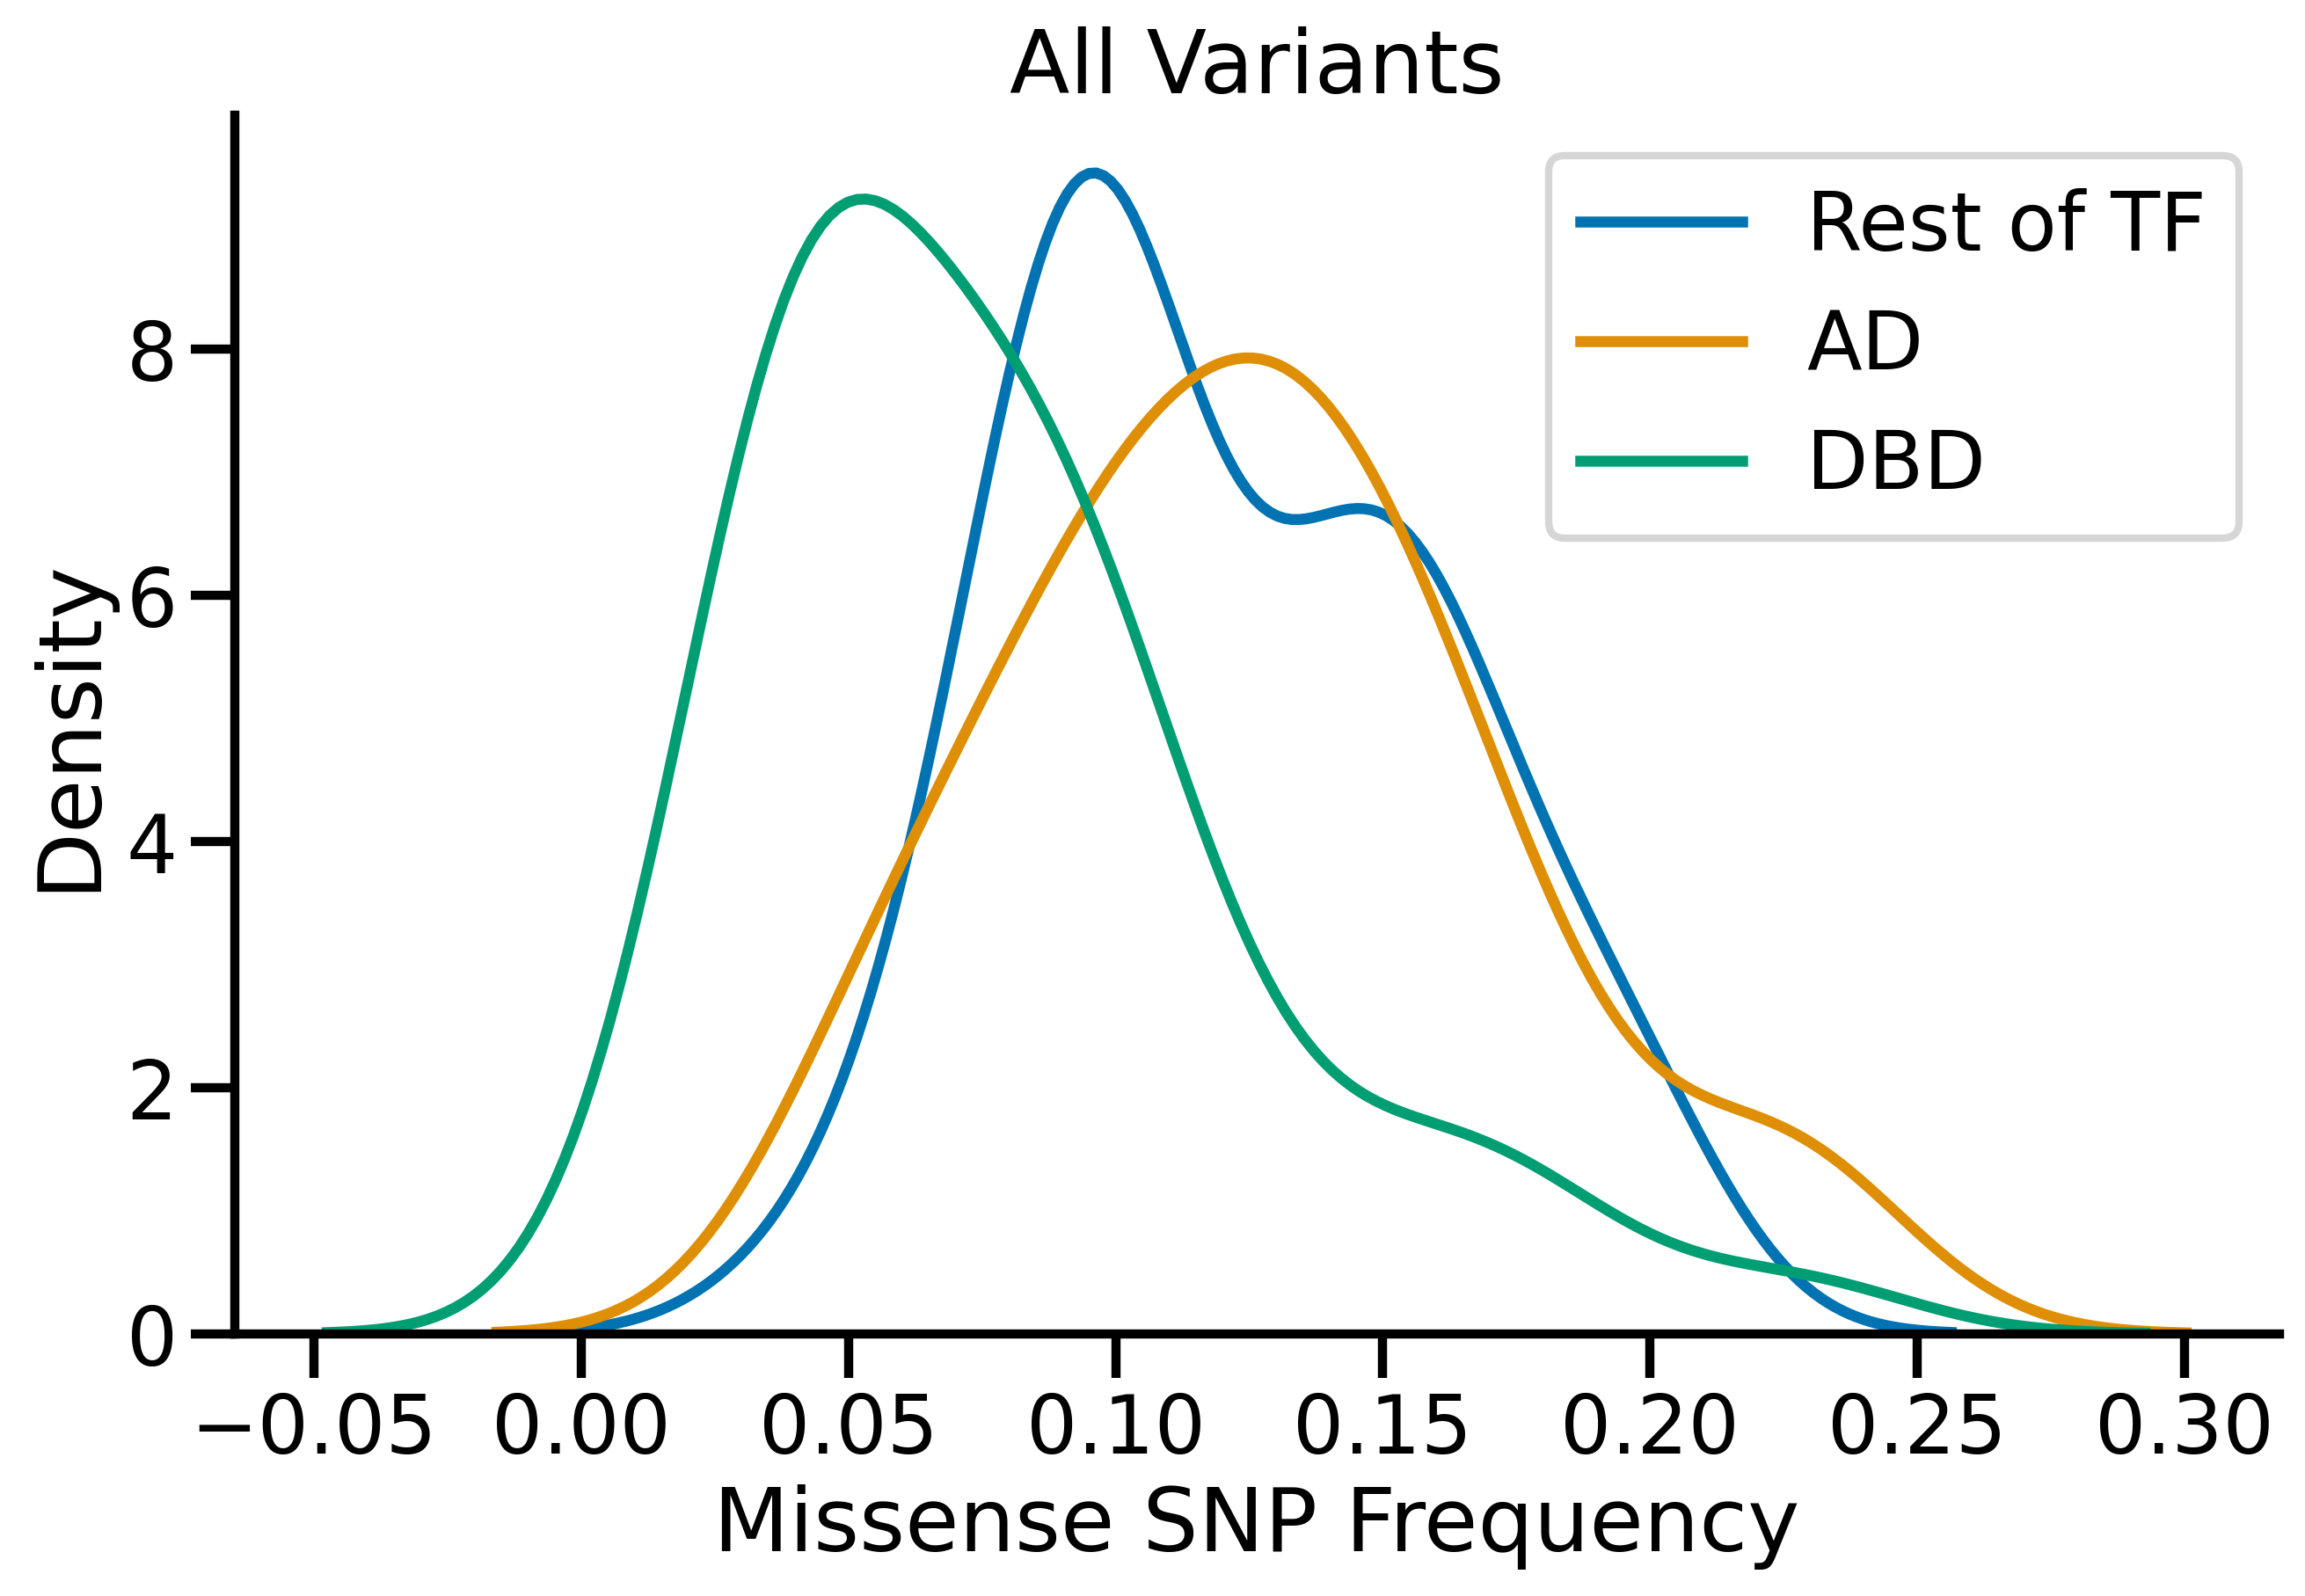

In [40]:
palette = sns.color_palette('colorblind')
sns.set_context('poster')
plt.figure(figsize = (10, 6), dpi = 300)


rest_of_TF_prop = (output["TF_missense"] - output["AD_missense"]) \
/ (output["TF_cds_length"] - output["AD_cds_length"])

sns.kdeplot(rest_of_TF_prop, label = "Rest of TF", color = palette[0]);
sns.kdeplot(output["AD_missense_prop"], color = palette[1], label = "AD");
sns.kdeplot(output["DBD_missense_prop"], color = palette[2], label = "DBD");


plt.legend()
plt.xlabel("Missense SNP Frequency")
plt.title("All Variants")
sns.despine()

In [29]:
for gene in set(contains_DBD_sig["gene-symbol"]) | set(sig_output["gene-symbol"]):
    print(gene)

KDM5B
OTX1
NKX2-2
AR
PAX6
CAMTA2
ESR2
EGR3
MTF1
IKZF1
TCF7L2
ARNT2
YY1
ARX
NR4A2
PITX1
GLIS1
TFE3
KLF16
NR1D1
HIVEP3
MEIS2
MYT1L
KLF7
PAX5
RORA
ERG
CASZ1


In [55]:
len(set(contains_DBD_sig["gene-symbol"]) or set(sig_output["gene-symbol"]))

24

In [6]:
hit_genes = [
    "TFE3", "CASZ1", "CAMTA2", "ARNT2", "YY1", "ERG", "PAX5", "MEIS2", "ESR2",
    "NR1D1", "OTX1", "PITX1", "RORA", "HIVEP3", "NKX2-2", "PAX6", "KLF7",
    "NR4A2", "AR", "KDM5B", "GLIS1", "ARX", "TCF7L2", "EGR3", "MYT1L",
    "MTF1", "IKZF1", "KLF16"
]


In [23]:
known_ADs = pd.read_csv("../../output/known_ADs_considering_isoforms_and_canonical.csv")
hit_gene_ADs = known_ADs[known_ADs["Gene"].isin(hit_genes)]
hit_gene_ADs = hit_gene_ADs[~hit_gene_ADs["uniprotID"].str.contains("-")]
hit_gene_ADs["AD Length"] = hit_gene_ADs["ProteinRegionSeq"].str.len()
hit_gene_ADs[["Gene", "AD Length"]].groupby("Gene")["AD Length"].apply(list).reset_index()

,Gene,AD Length
0,AR,"[494, 259]"
1,ARNT2,[194]
2,ARX,[91]
3,CAMTA2,"[184, 110]"
4,CASZ1,[155]
5,EGR3,[202]
6,ERG,"[47, 144]"
7,ESR2,"[148, 197]"
8,GLIS1,[174]
9,HIVEP3,[864]
